Average over selected organs (mean per organ first, then mean over organs):

dice after:
  transmorph_l7000_k10: 0.7096
  transmorph_ctsmoothness_l7000_k10_mar3000_gam2.0: 0.7106
  transmorph_l7000_k10_ctinput: 0.7430
  transmorph_ctsmoothness_l7000_k10_ctinput_mar3000_gam2.0: 0.7396
  transmorph_l7000_k10_ctinput_diffeomorphic_s0.5_i7: 0.7258
  transmorph_l7000_k10_ctinput_ctsmoothness_mar3000_gam2_diffeomorphic_s0.5_i7: 0.7360
  voxelmorph_l7000_k10: 0.7247
  voxelmorph_ctsmoothness_l7000_k10_mar3000_gam2.0: 0.7201
  voxelmorph_l7000_k10_ctinput: 0.7316
  voxelmorph_ctsmoothness_l7000_k10_ctinput_mar3000_gam2.0: 0.7479
  voxelmorph_l7000_k10_ctinput_diffeomorphic_s0.5_i7: 0.7342
  voxelmorph_l7000_k10_ctinput_ctsmoothness_mar3000_gam2_diffeomorphic_s0.5_i7: 0.7368

tre after:
  transmorph_l7000_k10: 5.4966
  transmorph_ctsmoothness_l7000_k10_mar3000_gam2.0: 5.5385
  transmorph_l7000_k10_ctinput: 4.9202
  transmorph_ctsmoothness_l7000_k10_ctinput_mar3000_gam2.0: 4.9511
  transmorph_l7

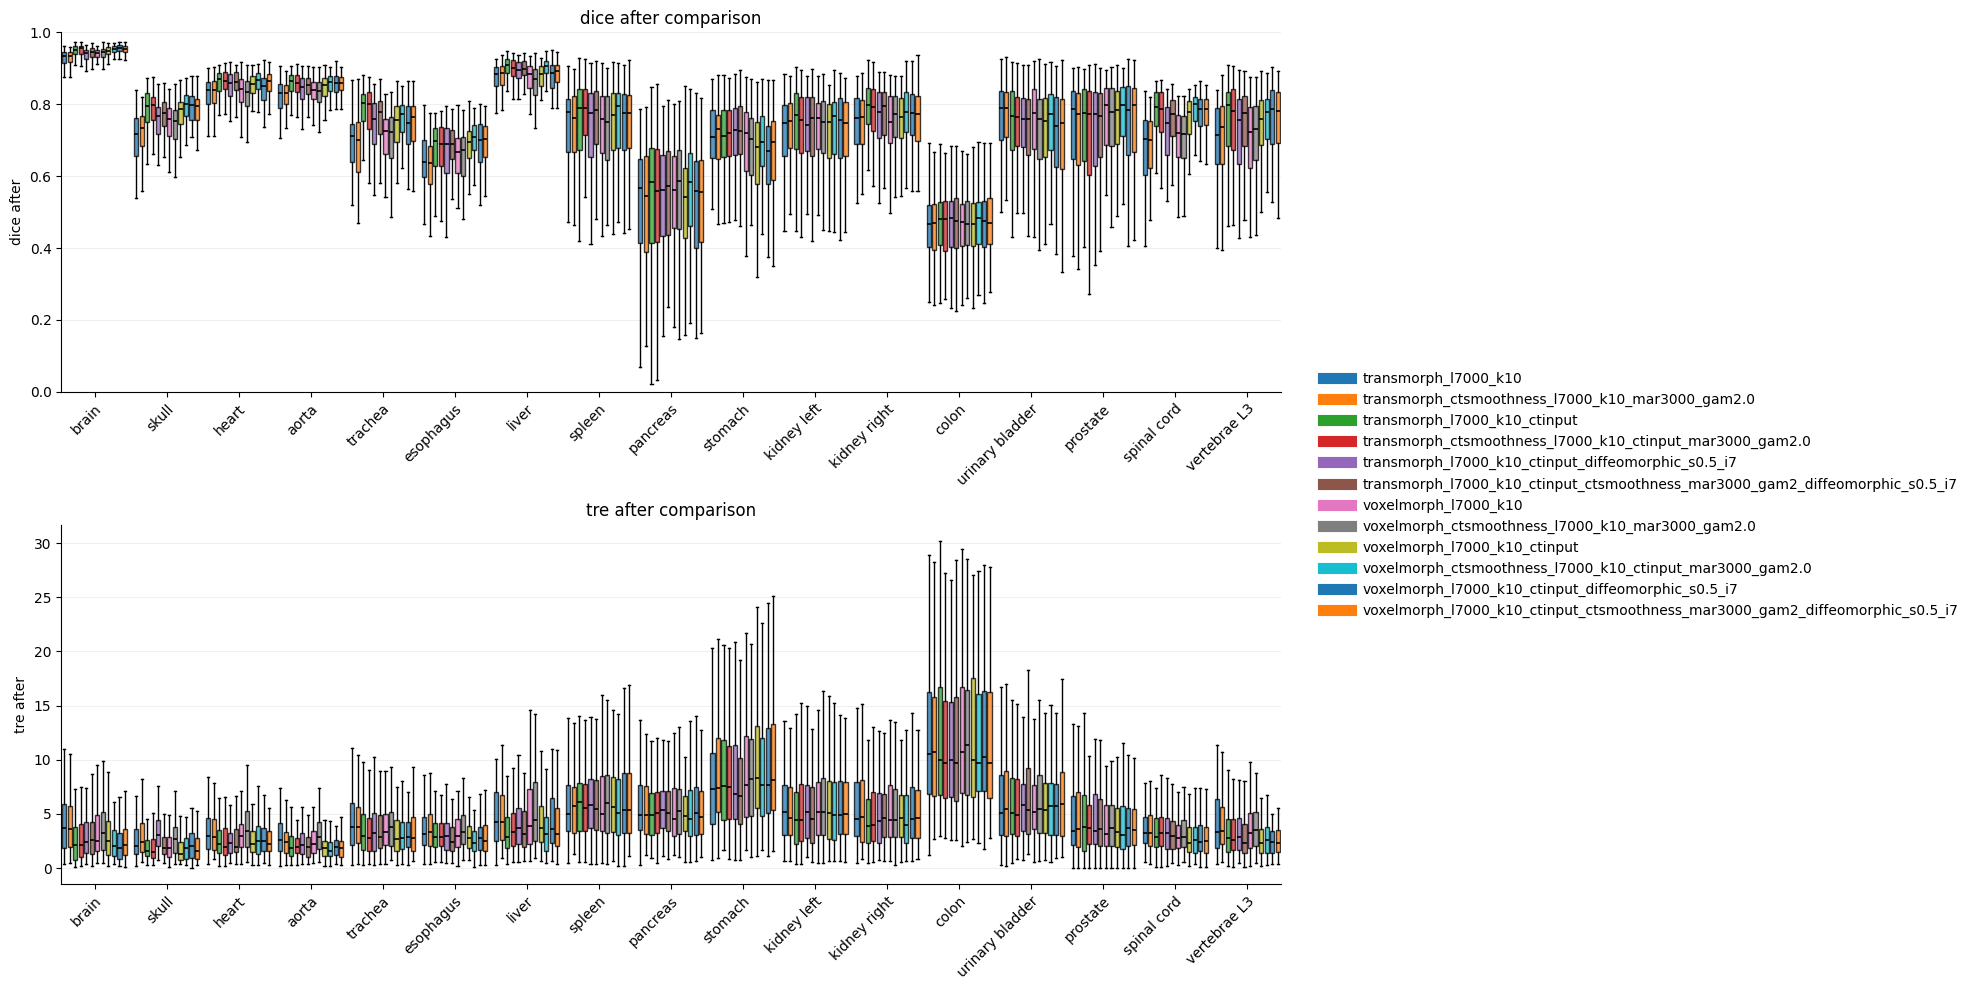

In [11]:
import ast
import os

import matplotlib.pyplot as plt
import numpy as np

DEFAULT_ORGANS = [
    "brain",
    "skull",
    "heart",
    "aorta",
    "trachea",
    "esophagus",
    "liver",
    "spleen",
    "pancreas",
    "stomach",
    "kidney_left",
    "kidney_right",
    "colon",
    "urinary_bladder",
    "prostate",
    "spinal_cord",
    "vertebrae_L3",
]

TXT_FILES = [
    "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_ctsmoothness_l7000_k10_mar3000_gam2.0.txt",

    "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10_ctinput.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_ctsmoothness_l7000_k10_ctinput_mar3000_gam2.0.txt",

    "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10_ctinput_diffeomorphic_s0.5_i7.txt",
    "/share/home/xcwu/pet_reg_results/transmorph_l7000_k10_ctinput_ctsmoothness_mar3000_gam2_diffeomorphic_s0.5_i7.txt",

    "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_ctsmoothness_l7000_k10_mar3000_gam2.0.txt",

    "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10_ctinput.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_ctsmoothness_l7000_k10_ctinput_mar3000_gam2.0.txt",

    "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10_ctinput_diffeomorphic_s0.5_i7.txt",
    "/share/home/xcwu/pet_reg_results/voxelmorph_l7000_k10_ctinput_ctsmoothness_mar3000_gam2_diffeomorphic_s0.5_i7.txt",
]

LABELS = None

# 单指标绘图时仍可使用 METRIC；main 里默认改为画 Dice + TRE 两行。
METRIC = "dice_after"
METRICS = ["dice_after", "tre_after"]

# 想额外打印 Dice / TRE 的 organs，在这里改
PRINT_SELECTED_ORGANS = [
    "urinary_bladder",
]

# 想额外打印的指标，在这里改
PRINT_SELECTED_METRICS = [
    "dice_before",
    "dice_after",
    "tre_before",
    "tre_after",
]

ORGANS = DEFAULT_ORGANS
USE_HORIZONTAL = False
SHOW_FLIERS = False
TITLE = None
OUTPUT = None


def parse_list_line(line):
    values = []
    for part in line.strip().split(";"):
        part = part.strip()
        try:
            values.append(ast.literal_eval(part))
        except Exception:
            values.append(part)
    return values


def load_registration_results(filename):
    """
    Load one registration result txt produced by Registration/inferencing.py.

    Returns:
        dict with masks_names, dice_before, dice_after, tre_before, tre_after.
    """
    with open(filename, "r") as f:
        lines = f.readlines()

    if len(lines) < 5:
        raise ValueError(
            f"{filename} should contain at least 5 lines: masks, dice before, "
            "dice after, TRE before, TRE after."
        )

    return {
        "masks_names": parse_list_line(lines[0]),
        "dice_before": parse_list_line(lines[1]),
        "dice_after": parse_list_line(lines[2]),
        "tre_before": parse_list_line(lines[3]),
        "tre_after": parse_list_line(lines[4]),
    }


def common_organs(results):
    common = set(results[0]["masks_names"])
    for result in results[1:]:
        common &= set(result["masks_names"])

    return [organ for organ in results[0]["masks_names"] if organ in common]


def choose_organs(results, organs, use_default_organs):
    available = common_organs(results)

    if organs:
        missing = [organ for organ in organs if organ not in available]
        if missing:
            raise ValueError(
                "These organs are missing from at least one txt file: "
                + ", ".join(missing)
            )
        return organs

    if use_default_organs:
        selected = [organ for organ in DEFAULT_ORGANS if organ in available]
        if selected:
            return selected

    return available


def collect_metric_data(results, metric, selected_organs):
    all_data = []

    for result in results:
        masks_names = result["masks_names"]
        metric_lists = result[metric]
        data_for_file = []

        for organ in selected_organs:
            organ_index = masks_names.index(organ)
            data_for_file.append(np.asarray(metric_lists[organ_index], dtype=float))

        all_data.append(data_for_file)

    return all_data


def make_colors(num_items):
    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(num_items)]


def metric_display_name(metric):
    return metric.replace("_", " ")


def average_over_organs(data_for_file):
    """
    先对每个 organ 的所有 case 求平均，再对所有 organ 的平均值求平均。
    这样每个 organ 权重相同，不会因为某个 organ 的 case 更多而权重更大。
    """
    organ_means = []

    for values in data_for_file:
        values = np.asarray(values, dtype=float)
        values = values[~np.isnan(values)]

        if values.size > 0:
            organ_means.append(float(np.mean(values)))

    if not organ_means:
        return np.nan

    return float(np.mean(organ_means))


def compute_metric_averages(results, labels, selected_organs, metric):
    metric_data = collect_metric_data(results, metric, selected_organs)

    return {
        label: average_over_organs(data_for_file)
        for label, data_for_file in zip(labels, metric_data)
    }


def print_metric_averages(results, labels, selected_organs, metrics):
    print("Average over selected organs (mean per organ first, then mean over organs):")

    for metric in metrics:
        averages = compute_metric_averages(results, labels, selected_organs, metric)

        print(f"\n{metric_display_name(metric)}:")
        for label in labels:
            value = averages[label]

            if np.isnan(value):
                print(f"  {label}: nan")
            else:
                print(f"  {label}: {value:.4f}")


def print_selected_organ_metrics(results, labels, organs_to_print, metrics_to_print):
    """
    Print selected metrics statistics for selected organs.

    For each metric, each organ, and each method, print:
        mean, std, median, n

    Example:
        selected organ dice after
        selected organ tre after
    """
    if not organs_to_print or not metrics_to_print:
        return

    available = common_organs(results)
    missing = [organ for organ in organs_to_print if organ not in available]

    if missing:
        raise ValueError(
            "These organs are missing from at least one txt file: "
            + ", ".join(missing)
        )

    for metric in metrics_to_print:
        print(f"\nSelected organ {metric_display_name(metric)}:")
        print("=" * 80)

        for organ in organs_to_print:
            print(f"\n{organ}:")

            for label, result in zip(labels, results):
                if metric not in result:
                    raise ValueError(f"Metric {metric} not found in result.")

                organ_index = result["masks_names"].index(organ)
                values = np.asarray(result[metric][organ_index], dtype=float)
                values = values[~np.isnan(values)]

                if values.size == 0:
                    print(f"  {label}: nan")
                else:
                    print(
                        f"  {label}: "
                        f"mean={np.mean(values):.4f}, "
                        f"std={np.std(values):.4f}, "
                        f"median={np.median(values):.4f}, "
                        f"n={values.size}"
                    )


def plot_metric_boxplot(
    results,
    labels,
    selected_organs,
    metric="dice_after",
    title=None,
    orientation="vertical",
    show_fliers=False,
    ax=None,
    add_legend=True,
):
    """
    Plot grouped boxplots. Each txt file becomes one boxplot series.
    If ax is provided, draw into that axis. Otherwise create a new figure.
    """
    metric_data = collect_metric_data(results, metric, selected_organs)
    num_organs = len(selected_organs)
    num_files = len(results)

    if num_organs == 0:
        raise ValueError("No organs selected for plotting.")

    colors = make_colors(num_files)
    group_spacing = num_files + 1
    positions_base = np.arange(num_organs) * group_spacing
    box_width = 0.75

    if ax is None:
        if orientation == "horizontal":
            fig, ax = plt.subplots(figsize=(9, max(5, num_organs * 0.45)))
        else:
            fig, ax = plt.subplots(figsize=(max(14, num_organs * 0.9), 6))
    else:
        fig = ax.figure

    for file_index, (data_for_file, label) in enumerate(zip(metric_data, labels)):
        offset = file_index - (num_files - 1) / 2
        positions = positions_base + offset

        boxplot_kwargs = {
            "positions": positions,
            "widths": box_width,
            "patch_artist": True,
            "showfliers": show_fliers,
            "flierprops": {
                "marker": "o",
                "markersize": 3,
                "linestyle": "none",
                "markerfacecolor": "black",
                "alpha": 0.45,
            },
        }

        if orientation == "horizontal":
            boxplot_kwargs["vert"] = False

        bp = ax.boxplot(data_for_file, **boxplot_kwargs)

        for patch in bp["boxes"]:
            patch.set_facecolor(colors[file_index])
            patch.set_alpha(0.75)

        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)

        # 用于图例的空线条
        ax.plot([], [], color=colors[file_index], linewidth=8, label=label)

    clean_organs = [organ.replace("_", " ") for organ in selected_organs]

    if orientation == "horizontal":
        ax.set_yticks(positions_base)
        ax.set_yticklabels(clean_organs)
        ax.set_xlabel(metric_display_name(metric))

        if metric.startswith("dice"):
            ax.set_xlim(0, 1)

    else:
        ax.set_xticks(positions_base)
        ax.set_xticklabels(
            clean_organs,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
        ax.set_ylabel(metric_display_name(metric))

        if metric.startswith("dice"):
            ax.set_ylim(0, 1)

    if title:
        ax.set_title(title)

    if add_legend:
        ax.legend(
            ncol=1,
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1, 0.5),
            fontsize="medium",
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x" if orientation == "horizontal" else "y", alpha=0.2)

    if add_legend:
        fig.tight_layout(rect=[0, 0, 0.85, 1])

    return fig, ax


def default_label_from_path(path):
    return os.path.splitext(os.path.basename(path))[0]


def plot_boxplots_from_txt_files(
    txt_files,
    labels=None,
    metric="dice_after",
    organs=None,
    use_horizontal=False,
    show_fliers=False,
    title=None,
    output=None,
    print_average=True,
):
    """
    Backward-compatible single-metric plotting function.
    """
    results = [load_registration_results(path) for path in txt_files]

    if labels is None:
        labels = [default_label_from_path(path) for path in txt_files]

    if len(labels) != len(txt_files):
        raise ValueError("labels must have the same length as txt_files.")

    selected_organs = choose_organs(
        results,
        organs=organs,
        use_default_organs=False,
    )

    if print_average:
        print_metric_averages(results, labels, selected_organs, [metric])

    if title is None:
        title = f"{metric_display_name(metric)} comparison"

    fig, _ = plot_metric_boxplot(
        results,
        labels,
        selected_organs,
        metric=metric,
        title=title,
        orientation="horizontal" if use_horizontal else "vertical",
        show_fliers=show_fliers,
    )

    if output:
        fig.savefig(output, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {output}")

    plt.show()

    return fig


def plot_metrics_boxplots_from_txt_files(
    txt_files,
    labels=None,
    metrics=None,
    organs=None,
    use_horizontal=False,
    show_fliers=False,
    title=None,
    output=None,
    print_averages=True,
    print_selected_organs=None,
    print_selected_metrics=None,
):
    """
    Plot multiple metrics in separate rows, e.g. Dice in the first row and TRE in the second row.

    Also print:
        1. average score for each method over selected organs
        2. selected organ Dice / TRE statistics, if requested
    """
    if metrics is None:
        metrics = ["dice_after", "tre_after"]

    results = [load_registration_results(path) for path in txt_files]

    if labels is None:
        labels = [default_label_from_path(path) for path in txt_files]

    if len(labels) != len(txt_files):
        raise ValueError("labels must have the same length as txt_files.")

    selected_organs = choose_organs(
        results,
        organs=organs,
        use_default_organs=False,
    )

    if print_averages:
        print_metric_averages(results, labels, selected_organs, metrics)

    if print_selected_organs and print_selected_metrics:
        print_selected_organ_metrics(
            results,
            labels,
            print_selected_organs,
            print_selected_metrics,
        )

    num_metrics = len(metrics)
    num_organs = len(selected_organs)

    if use_horizontal:
        figsize = (9, max(5, num_organs * 0.45) * num_metrics)
    else:
        figsize = (max(14, num_organs * 0.9), 5 * num_metrics)

    fig, axes = plt.subplots(num_metrics, 1, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics):
        plot_metric_boxplot(
            results,
            labels,
            selected_organs,
            metric=metric,
            title=f"{metric_display_name(metric)} comparison",
            orientation="horizontal" if use_horizontal else "vertical",
            show_fliers=show_fliers,
            ax=ax,
            add_legend=False,
        )

    handles, legend_labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        legend_labels,
        ncol=1,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(0.86, 0.5),
        fontsize="medium",
    )

    if title:
        fig.suptitle(title)
        fig.tight_layout(rect=[0, 0, 0.85, 0.95])
    else:
        fig.tight_layout(rect=[0, 0, 0.85, 1])

    if output:
        fig.savefig(output, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {output}")

    plt.show()

    return fig


def main():
    if not TXT_FILES:
        raise ValueError("Please fill TXT_FILES with one or more result txt paths.")

    plot_metrics_boxplots_from_txt_files(
        TXT_FILES,
        labels=LABELS,
        metrics=METRICS,
        organs=ORGANS,
        use_horizontal=USE_HORIZONTAL,
        show_fliers=SHOW_FLIERS,
        title=TITLE,
        output=OUTPUT,
        print_averages=True,
        print_selected_organs=PRINT_SELECTED_ORGANS,
        print_selected_metrics=PRINT_SELECTED_METRICS,
    )


if __name__ == "__main__":
    main()